# Chest X-ray Classifier

**Cutting-Edge AI for the Future of Healthcare**
---

## Executive Summary

This project develops an AI-powered multi-label classification system to detect 14 thoracic pathologies from chest X-ray images using deep learning. Leveraging the NIH ChestX-ray8 dataset containing 5,000 frontal-view X-ray images, I implement transfer learning with DenseNet121 to create a robust diagnostic assistance tool.

The model performs simultaneous binary classification for 14 pathological conditions: Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural Thickening, Pneumonia, and Pneumothorax. This multi-label approach reflects real clinical scenarios where patients often present with multiple co-occurring conditions.

*Note: The labels of the 14 pathological conditions were identified by a Natural Language Processing Model which extracted disease labels from free-text radiology reports. The labels produced from the model were not verified for their correctness by trained radiologists.*

**Clinical Significance**

Accurate automated detection of these pathologies can:
- Accelerate diagnosis in emergency departments
- Reduce missed findings in high-volume screening
- Provide second opinions to improve diagnostic accuracy
- Enable early intervention for critical conditions like Pneumothorax
- Extend diagnostic capabilities to resource-limited settings

**Technical Approach:**
- **Transfer Learning:** Fine-tuned pretrained DenseNet121 (ImageNet weights) for medical image classification
- **Class Imbalance Handling:** Implemented weighted Binary Cross-Entropy loss to address severe class imbalance (some diseases <1% prevalence)
- **Comprehensive Evaluation:** Multi-metric assessment using AUC-ROC, Average Precision, and F1-score for clinical relevance
- **Model Interpretability:** GradCAM visualization to understand spatial attention and build clinical trust
- **Robust Validation:** Stratified train/validation/test split ensuring representative class distribution across all subsets

The model is designed as a **screening tool** rather than a replacement for radiologists, optimized to identify patients with pathological conditions requiring urgent attention while minimizing false negatives in critical conditions.

**Key Technologies:** PyTorch, DenseNet121, scikit-learn, GradCAM, multi-label stratification, weighted loss functions

---

## Introduction to Classification

Classification is a supervised learning task where algorithms learn from labeled data to assign new, unseen data points into predefined discrete categories or classes. In this project, we implement **multi-label classification**, where each X-ray image can simultaneously belong to multiple disease classes, reflecting real-world clinical scenarios.

**Key Characteristics:**
- **Supervised Learning:** The model learns from a dataset where each X-ray is labeled with the presence or absence of 14 different pathological conditions.
- **Multi-Label Output:** Unlike traditional binary or multi-class classification, each input can have multiple positive labels (e.g., a patient may have both Effusion and Cardiomegaly).
- **Deep Learning Architecture:** We use Convolutional Neural Networks (CNNs), specifically DenseNet121, which excel at learning hierarchical visual features from raw pixel data.
- **Transfer Learning:** Rather than training from scratch, we leverage a model pretrained on millions of natural images (ImageNet) and fine-tune it for medical imaging, dramatically reducing training time and improving performance.
- **Imbalanced Data Challenge:** Medical datasets often have severe class imbalance (e.g., rare diseases <1% prevalence), requiring specialized loss functions and evaluation metrics.

**Why Deep Learning for Medical Imaging?**
Deep learning models can automatically learn complex visual patterns that are difficult to handcraft, such as subtle opacity differences, texture variations, and spatial relationships that indicate disease. CNNs process images through multiple layers, learning increasingly abstract features: from edges and textures in early layers to complex anatomical structures and pathological patterns in deeper layers.

## Problem Definition

**Research Question:** Can a deep learning model be developed to accurately detect and classify 14 thoracic pathologies from chest X-ray images, providing automated screening assistance to radiologists?

### Dataset Overview
**ChestX-ray8 Dataset** from the National Institutes of Health (NIH)

X. Wang, Y. Peng, L. Lu, Z. Lu, M. Bagheri and R. M. Summers, "ChestX-Ray8: Hospital-Scale Chest X-Ray Database and Benchmarks on Weakly-Supervised Classification and Localization of Common Thorax Diseases," 2017 IEEE Conference on Computer Vision and Pattern Recognition (CVPR), Honolulu, HI, USA, 2017, pp. 3462-3471, doi: 10.1109/CVPR.2017.369.

[Paper URL](http://dx.doi.org/10.1109/CVPR.2017.369)  
[Dataset URL](https://nihcc.app.box.com/v/ChestXray-NIHCC)

**Dataset Characteristics:**
- 5,000 frontal-view chest X-ray images
- Images sized 1024×1024 pixels in PNG format
- Multi-label annotations (images can have 0-14 pathology labels)
- Labels extracted from radiological reports using Natural Language Processing
- Severe class imbalance across pathologies

### Target Variables (Multi-Label Binary Classification)

Each of the following 14 pathologies are treated as an independent binary classification task:

| Disease | Type | Description | Approximate Prevalence |
|---------|------|-------------|------------------------|
| `Atelectasis` | Binary | Partial or complete lung collapse | ~11% |
| `Cardiomegaly`| Binary | Enlarged heart | ~2.5% |
| `Consolidation` | Binary | Lung tissue filled with liquid/solid material | ~4% |
| `Edema` | Binary | Fluid accumulation in lungs | ~2% |
| `Effusion` | Binary | Fluid between lung and chest wall | ~13% |
| `Emphysema` | Binary | Damaged air sacs in lungs | ~2% |
| `Fibrosis` | Binary | Lung tissue scarring | ~1.5% |
| `Hernia` | Binary | Organ pushes through muscle/tissue | <0.3% |
| `Infiltration` | Binary | Substance denser than air in lungs | ~17% |
| `Mass` | Binary | Lung lesion >3cm | ~5% |
| `Nodule` | Binary | Small lung lesion <3cm | ~6% |
| `Pleural Thickening` | Binary | Thickened pleural lining | ~3% |
| `Pneumonia` | Binary | Lung infection/inflammation | ~1.3% |
| `Pneumothorax` | Binary | Collapsed lung (air in pleural space) | ~5% |

**Additional Labels in Dataset:**
- `No Finding`: Binary indicator for normal X-rays without pathology (~60% of images)
- `Image Index`: Unique identifier for each X-ray image
- `Patient ID`: Unique identifier for each patient (multiple images per patient possible)

---

## Analysis Pipeline
1. **Data Loading & Inspection** - Load NIH ChestX-ray8 dataset and examine structure, dimensions, and label distribution
2. **Exploratory Data Analysis** - Analyze class imbalance, visualize sample images, and understand pathology co-occurrence patterns
3. **Data Preprocessing - Train/Val/Test Split** - Multi-label stratified split (70/15/15) to maintain class balance across all subsets
4. **Model Development** 
    - 4.1 **Calculate Dataset Statistics** - Compute mean and standard deviation for normalization
    - 4.2 **Image Transformations & DataLoaders** - Define preprocessing pipeline and create efficient data loading
    - 4.3 **Load Pretrained Model** - Initialize DenseNet121 with ImageNet weights and modify classifier
    - 4.4 **Calculate Class Weights** - Compute inverse-frequency weights to handle severe class imbalance
    - 4.5 **Define Loss Function & Optimizer** - Set up weighted BCE loss and Adam optimizer
5. **Model Training & Validation** - Train with early stopping, monitor validation metrics, and save best checkpoint
6. **Model Evaluation** - Assess performance on held-out test set using AUC-ROC, Average Precision, and F1-score
7. **ROC Curve Analysis** - Generate and visualize ROC curves for each disease to understand discrimination ability
8. **GradCAM Visualization** - Apply explainability technique to visualize model attention regions
9. **Interpretation & Recommendations** - Clinical insights, model limitations, and deployment considerations

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F  
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
from torchvision import models
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, roc_curve, auc
from scipy.ndimage import zoom  
from PIL import Image

import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

c:\Users\LE732\anaconda3\envs\pytorch_env\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Libraries imported successfully!


## 1. Load & Inspect Data

A 5,000-image subset was constructed using multilabel-aware stratification to preserve the marginal prevalence of each pathology while reducing dataset size and patient duplication. This approach maintains clinically realistic disease distributions while enabling efficient analysis.

In [2]:
df_subset = pd.read_csv('../data/subset.csv')

# Add disease labels to DF & image path
disease_labels = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
                  'Effusion','Emphysema', 'Fibrosis', 'Hernia', 'Infiltration',
                  'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia',
                  'Pneumothorax']

# Create binary columns for each disease
for label in disease_labels:
    df_subset[label] = df_subset['Finding Labels'].apply(
        lambda x: 1 if label in x else 0)

# Add image path to df
df_subset['image_path'] = df_subset['Image Index'].map(
    lambda fname: f"../images_subset_5000/{fname}")

# Inspection
print('='*80)
print('INITIAL DATA INSPECTION')
print('='*80)

# Store datasets in a dictionary
datasets = {'Dataset': df_subset}

# Loop through each dataset
for name, df in datasets.items():
    print('\nDataset Shape:')
    print('-'*60)
    print(f'Total samples: {df.shape[0]:,} | Features: {df.shape[1]}')
    
    print('\nFirst Few Rows:')
    print('-'*60)
    display(df.head())
    
    print('\nDataset Information:')
    print('-'*60)
    display(df.info())

INITIAL DATA INSPECTION

Dataset Shape:
------------------------------------------------------------
Total samples: 5,000 | Features: 26

First Few Rows:
------------------------------------------------------------


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax,image_path
0,00000097_000.png,No Finding,0,97,83,F,PA,2021,1865,0.194311,...,0,0,0,0,0,0,0,0,0,../images_subset_5000/00000097_000.png
1,00000174_000.png,No Finding,0,174,69,F,PA,2048,2500,0.168000,...,0,0,0,0,0,0,0,0,0,../images_subset_5000/00000174_000.png
2,00000174_001.png,Infiltration|Nodule,1,174,71,F,PA,2992,2991,0.143000,...,0,0,0,1,0,1,0,0,0,../images_subset_5000/00000174_001.png
3,00000174_002.png,Nodule,2,174,72,F,PA,2992,2991,0.143000,...,0,0,0,0,0,1,0,0,0,../images_subset_5000/00000174_002.png
4,00000174_003.png,No Finding,3,174,73,F,PA,2814,2991,0.143000,...,0,0,0,0,0,0,0,0,0,../images_subset_5000/00000174_003.png



Dataset Information:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5000 non-null   object 
 1   Finding Labels               5000 non-null   object 
 2   Follow-up #                  5000 non-null   int64  
 3   Patient ID                   5000 non-null   int64  
 4   Patient Age                  5000 non-null   int64  
 5   Patient Sex                  5000 non-null   object 
 6   View Position                5000 non-null   object 
 7   OriginalImage[Width          5000 non-null   int64  
 8   Height]                      5000 non-null   int64  
 9   OriginalImagePixelSpacing[x  5000 non-null   float64
 10  y]                           5000 non-null   float64
 11  Atelectasis                  5000 non-null   int64 

None

### Duplicate Check

In [3]:
# Check for duplicates
print('='*80)
print('CHECKING FOR DUPLICATE PATIENT IDs')
print('='*80)

total_images = len(df_subset)
unique_patients = df_subset['Patient ID'].nunique()
duplicate_count = total_images - unique_patients

print(f'\nTotal images: {total_images:,}')
print(f'Unique patients: {unique_patients:,}')
print(f'Duplicate patients: {duplicate_count:,}')

# Show patients with multiple images
patient_counts = df_subset['Patient ID'].value_counts()
patients_with_multiple = patient_counts[patient_counts > 1]

print(f'\nPatients with multiple images: {len(patients_with_multiple):,}')
print(f'Max images per patient: {patient_counts.max()}')

# Show example
print('\nExample - Top 5 patients with most images:')
print(patient_counts.head())

CHECKING FOR DUPLICATE PATIENT IDs

Total images: 5,000
Unique patients: 1,492
Duplicate patients: 3,508

Patients with multiple images: 616
Max images per patient: 75

Example - Top 5 patients with most images:
Patient ID
10352    75
28876    66
18360    65
13917    63
4342     62
Name: count, dtype: int64


## 2. Visual Analysis EDA

In [4]:
# Disease Distribution
freq_df = (
    pd.DataFrame({
        'Disease': disease_labels,
        'Positive (1)': [df_subset[d].sum() for d in disease_labels],})
    .assign(
        **{'Negative (0)': lambda x: len(df_subset) - x['Positive (1)'],
            'Percent (1)': lambda x: (x['Positive (1)'] / len(df_subset) * 100).round(2),
            'Percent (0)': lambda x: (x['Negative (0)'] / len(df_subset) * 100).round(2),}))

freq_df.reset_index(drop=True, inplace=True)
display(freq_df)

,Disease,Positive (1),Negative (0),Percent (1),Percent (0)
0,Atelectasis,492,4508,9.84,90.16
1,Cardiomegaly,164,4836,3.28,96.72
2,Consolidation,203,4797,4.06,95.94
3,Edema,92,4908,1.84,98.16
4,Effusion,625,4375,12.50,87.50
5,Emphysema,103,4897,2.06,97.94
6,Fibrosis,95,4905,1.90,98.10
7,Hernia,14,4986,0.28,99.72
8,Infiltration,854,4146,17.08,82.92
9,Mass,237,4763,4.74,95.26


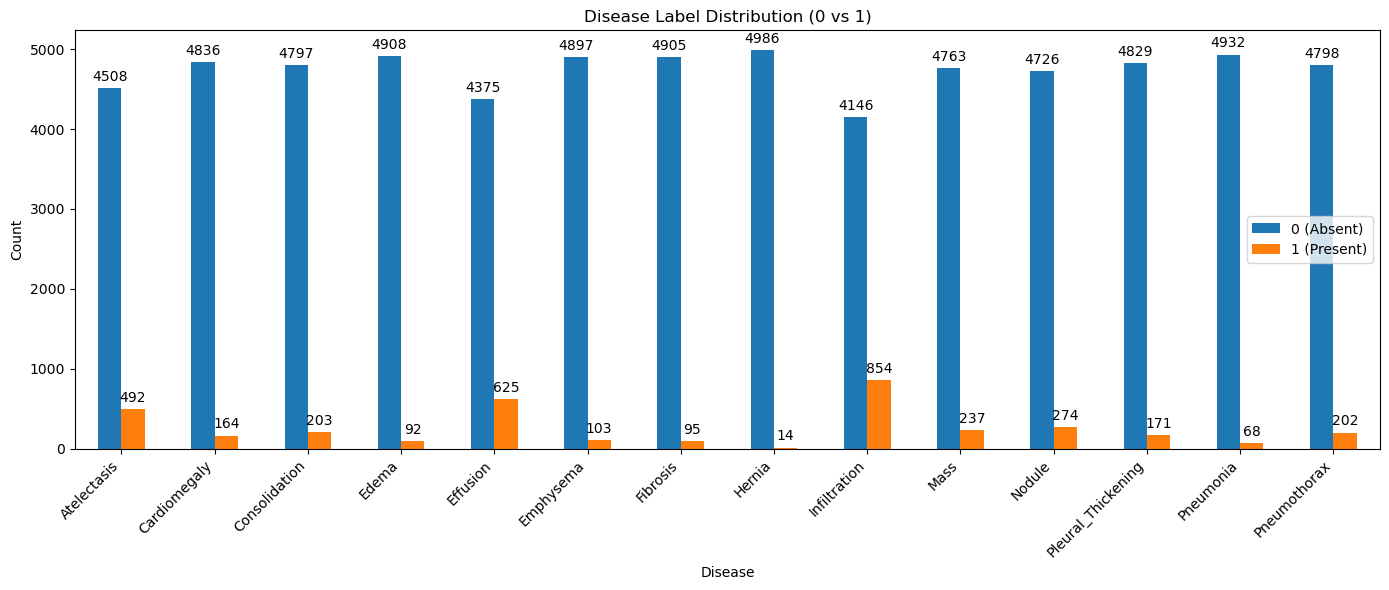

In [5]:
# Visual count of 0s and 1s per disease
counts = pd.DataFrame({
    disease: df_subset[disease].value_counts()
    for disease in disease_labels
}).T.fillna(0)

counts.columns = ['0 (Absent)', '1 (Present)']

# Plot
ax = counts.plot(
    kind='bar',
    figsize=(14, 6))

plt.title('Disease Label Distribution (0 vs 1)')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.show()

## 3. Data Preprocessing - Train/Val/Test Split
As noted earlier there are patients with multiple images and in order to prevent data leakage those patients will only be in either the train, validation, or test set. 

In [6]:
# Aggregate to patient level (multi-label OR)
patient_labels = (
    df_subset
    .groupby('Patient ID')[disease_labels]
    .max())

patients = patient_labels.index.values
y_multi = patient_labels.values

msss1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42)

train_val_idx, test_idx = next(
    msss1.split(patients, y_multi))

patients_train_val = patients[train_val_idx]
patients_test = patients[test_idx]
y_train_val = y_multi[train_val_idx]

# Split train+val into train / val
msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.176,
    random_state=42)

train_idx, val_idx = next(
    msss2.split(patients_train_val, y_train_val))

patients_train = patients_train_val[train_idx]
patients_val = patients_train_val[val_idx]

# Expand back to IMAGE-LEVEL dataframes
df_train = df_subset[df_subset['Patient ID'].isin(patients_train)].reset_index(drop=True)
df_val   = df_subset[df_subset['Patient ID'].isin(patients_val)].reset_index(drop=True)
df_test  = df_subset[df_subset['Patient ID'].isin(patients_test)].reset_index(drop=True)

assert set(patients_train).isdisjoint(patients_val)
assert set(patients_train).isdisjoint(patients_test)
assert set(patients_val).isdisjoint(patients_test)

print('✓ No patient overlap across splits')
print('Train Dataset: ',len(df_train))
print('Val Dataset: ',len(df_val))
print('Test Dataset: ',len(df_test))

✓ No patient overlap across splits
Train Dataset:  3587
Val Dataset:  680
Test Dataset:  733


In [7]:
# Verify stratification quality
for d in disease_labels:
    print(
        f"{d:20s} | "
        f"Train: {df_train[d].mean():.3f} | "
        f"Val: {df_val[d].mean():.3f} | "
        f"Test: {df_test[d].mean():.3f} | "
        f"Subset: {df_subset[d].mean():.3f} ")

Atelectasis          | Train: 0.099 | Val: 0.078 | Test: 0.116 | Subset: 0.098 
Cardiomegaly         | Train: 0.035 | Val: 0.038 | Test: 0.019 | Subset: 0.033 
Consolidation        | Train: 0.040 | Val: 0.044 | Test: 0.040 | Subset: 0.041 
Edema                | Train: 0.019 | Val: 0.019 | Test: 0.014 | Subset: 0.018 
Effusion             | Train: 0.139 | Val: 0.087 | Test: 0.090 | Subset: 0.125 
Emphysema            | Train: 0.020 | Val: 0.024 | Test: 0.020 | Subset: 0.021 
Fibrosis             | Train: 0.019 | Val: 0.019 | Test: 0.018 | Subset: 0.019 
Hernia               | Train: 0.002 | Val: 0.003 | Test: 0.005 | Subset: 0.003 
Infiltration         | Train: 0.170 | Val: 0.194 | Test: 0.151 | Subset: 0.171 
Mass                 | Train: 0.043 | Val: 0.046 | Test: 0.070 | Subset: 0.047 
Nodule               | Train: 0.053 | Val: 0.069 | Test: 0.049 | Subset: 0.055 
Pleural_Thickening   | Train: 0.036 | Val: 0.024 | Test: 0.037 | Subset: 0.034 
Pneumonia            | Train: 0.013 | Va

### Inspection of Images

Training Set Samples:


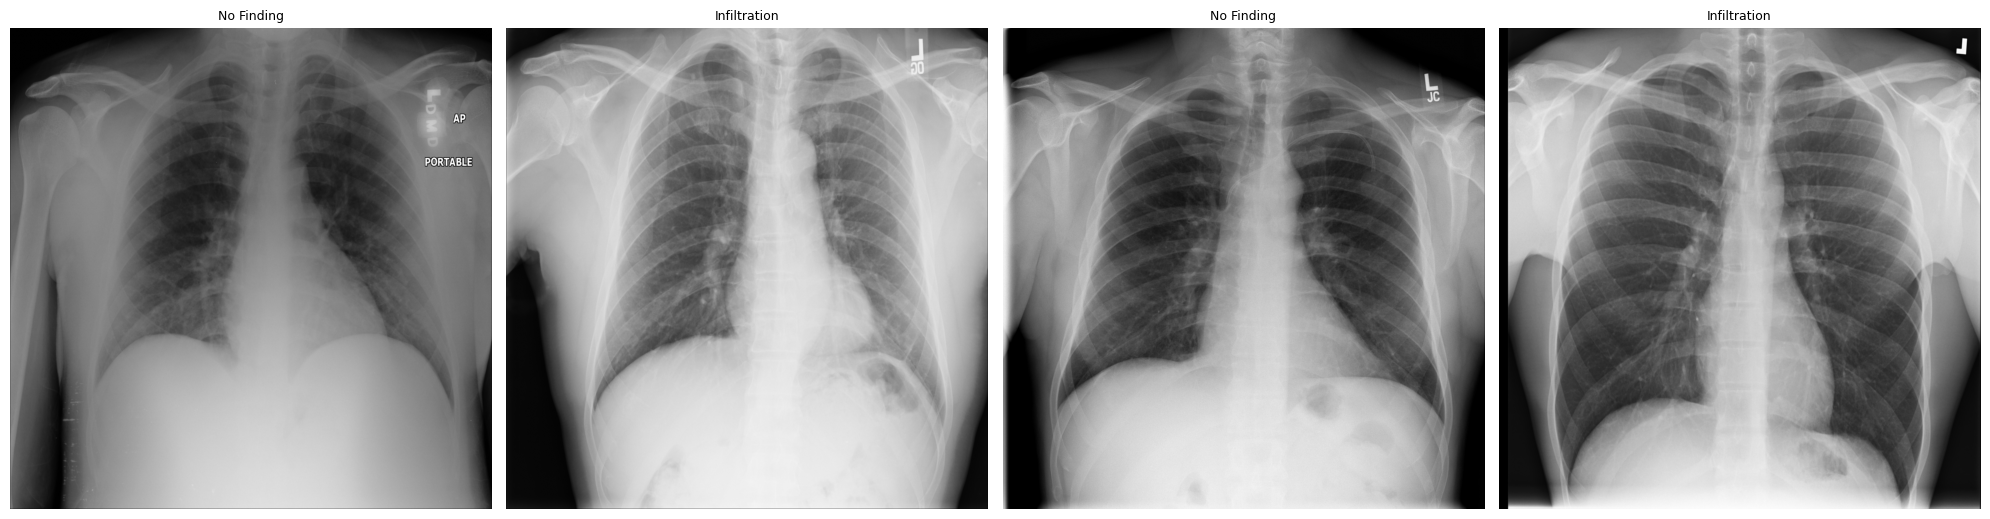


Validation Set Samples:


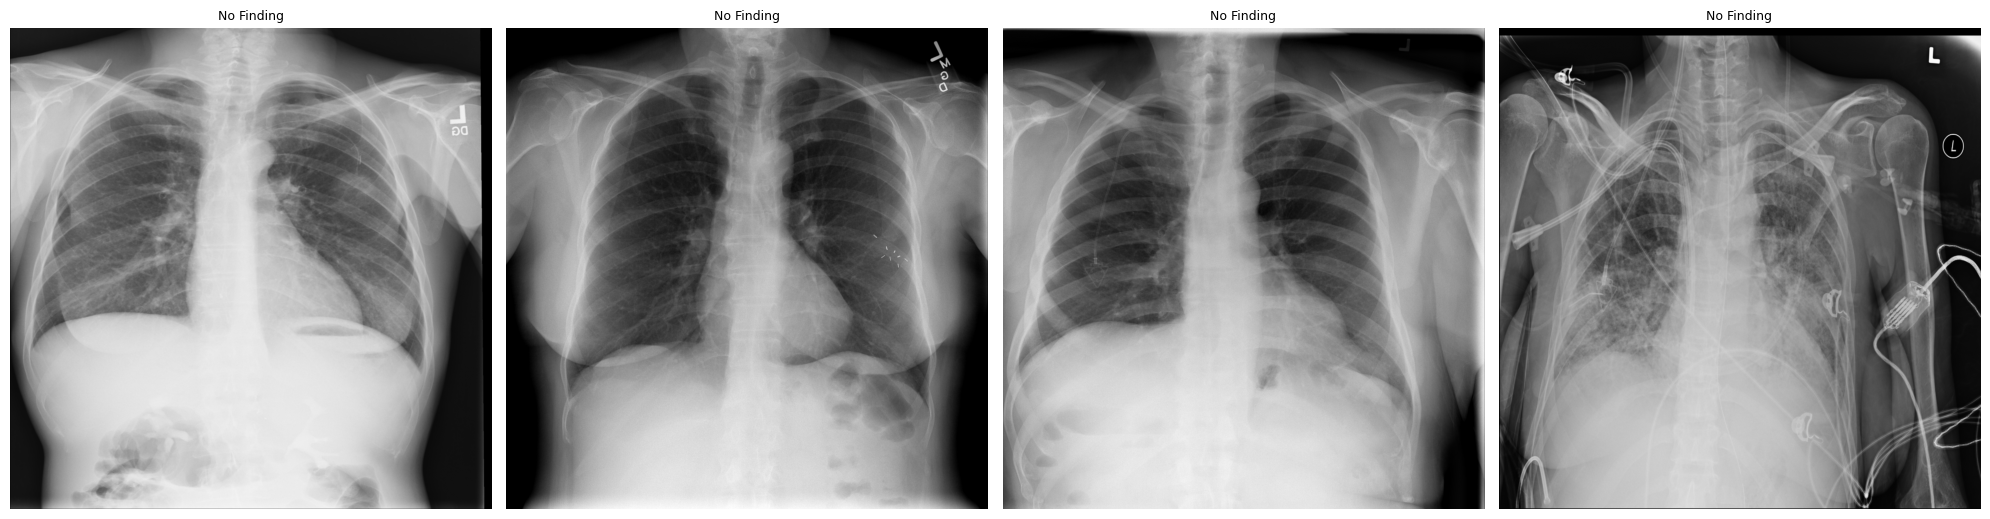


Test Set Samples:


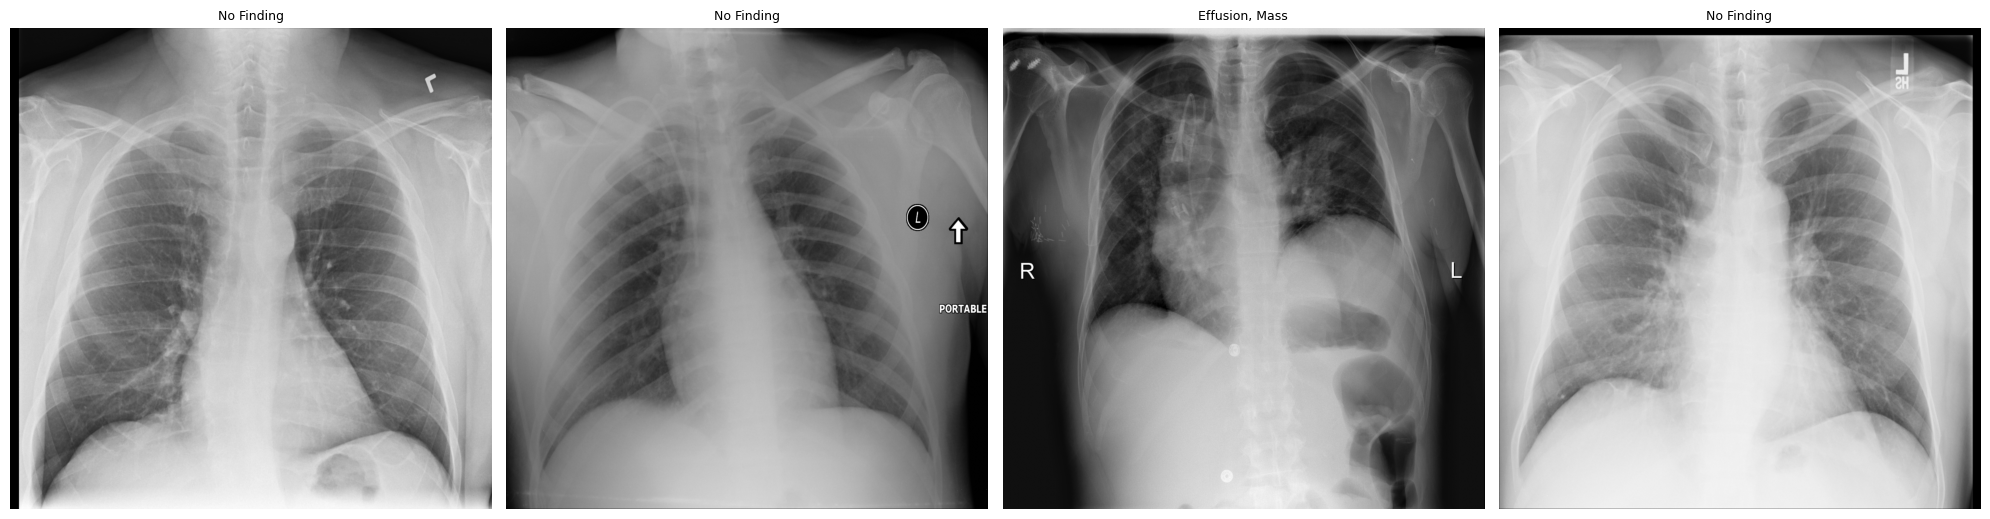

In [8]:
def display_sample_images(df, n_samples=4):
    """Display sample images using image_path column"""
    fig, axes = plt.subplots(1, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    samples = df.sample(n=min(n_samples, len(df)))
    
    for idx, (_, row) in enumerate(samples.iterrows()):
        # Load directly from path
        img = Image.open(row['image_path'])
        
        # Get active diseases
        active_diseases = [label for label in disease_labels if row[label] == 1]
        label_text = ', '.join(active_diseases) if active_diseases else 'No Finding'
        
        axes[idx].imshow(img, cmap='gray')
        axes[idx].set_title(f"{label_text}", fontsize=9)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# View samples from each dataset
print("Training Set Samples:")
display_sample_images(df_train)

print("\nValidation Set Samples:")
display_sample_images(df_val)

print("\nTest Set Samples:")
display_sample_images(df_test)

## 4. Model Development with PyTorch

### 4.1 Calculate Mean & Std from Training Images

In [9]:
from tqdm import tqdm

def comprehensive_image_analysis(df, n_samples=200):
    if n_samples and n_samples < len(df):
        sample_df = df.sample(n=n_samples, random_state=42)
    else:
        sample_df = df
    
    print(f'\nAnalyzing {len(sample_df)} images...')
    
    # Collect data
    resolutions = []
    all_pixels = []
    
    for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Processing images"):
        try:
            img = Image.open(row['image_path']).convert('L')
            img_array = np.array(img) / 255.0
            resolutions.append((img.size[0], img.size[1]))
            all_pixels.extend(img_array.flatten())
        except Exception as e:
            print(f"\nError: {row['image_path']}: {e}")
            continue
    
    all_pixels = np.array(all_pixels)
    
    # Print Statistics
    print('\n' + '='*80)
    print('PIXEL INTENSITY STATISTICS')
    print('='*80)
    overall_mean = all_pixels.mean()
    overall_std = all_pixels.std()
    
    print(f'\nDataset-wide (all pixels):')
    print(f'  Mean:    {overall_mean:.4f}')
    print(f'  Std Dev: {overall_std:.4f}')
  
    return {
        'mean': overall_mean,
        'std': overall_std,
        'resolutions': resolutions,}

train_stats = comprehensive_image_analysis(df_train, n_samples=200)


Analyzing 200 images...


Processing images: 100%|██████████| 200/200 [00:19<00:00, 10.08it/s]



PIXEL INTENSITY STATISTICS

Dataset-wide (all pixels):
  Mean:    0.4971
  Std Dev: 0.2508


### 4.2 Image Transformation, Datasets and DataLoaders  

In [10]:
# ============================================================================
# STEP 1: Define Image Transforms
# ============================================================================
# Calculated statistics
MEAN = train_stats['mean']  # Use your actual calculated mean
STD = train_stats['std']   # Use your actual calculated std

#MEAN = 0.4971
#STD = 0.2508

# Training transforms (with augmentation) modify image & turn into tensor
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale
    
    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    
    # Normalization
    transforms.ToTensor(),  # Converts to 0-1 and CHW format
    transforms.Normalize(mean=[MEAN, MEAN, MEAN], 
                        std=[STD, STD, STD])])

# Validation/Test transforms (NO augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[MEAN, MEAN, MEAN], 
                        std=[STD, STD, STD])])

# ============================================================================
# STEP 2: Create Dataset Class
# ============================================================================
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['image_path']).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        labels = torch.tensor(row[disease_labels].values.astype(float))
        return image, labels

# ============================================================================
# STEP 3: Create Datasets and DataLoaders (run once)
# ============================================================================
# Datasets
train_dataset = CXRDataset(df_train, transform=train_transform)
val_dataset = CXRDataset(df_val, transform=val_test_transform)
test_dataset = CXRDataset(df_test, transform=val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f'✓ Data loaders ready')
print(f'  Training batches: {len(train_loader)}')
print(f'  Validation batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

✓ Data loaders ready
  Training batches: 57
  Validation batches: 11
  Test batches: 12


 ### 4.3 Calculate Class Weights,Load Model, Define Loss Function, and Optimizer
 Weight the loss by inverse class frequency:

In [11]:
# ============================================================================
# STEP 4: Calculate Class Weights
# ============================================================================
print('\n' + '='*80)
print('CALCULATING CLASS WEIGHTS')
print('='*80)

# Count positives (how many images have each disease)
pos_counts = df_train[disease_labels].sum()

# Count negatives (how many images DON'T have each disease)
neg_counts = len(df_train) - pos_counts

# Calculate weights: more weight for rare diseases
pos_weights = neg_counts / pos_counts

# Show the weights
print('\nClass Weights:')
print('-'*60)
for disease in disease_labels:
    print(f'{disease:20s}: {pos_weights[disease]:6.2f}  ({pos_counts[disease]:4.0f} images)')

# Convert to PyTorch tensor
pos_weights_tensor = torch.FloatTensor(pos_weights.values)


CALCULATING CLASS WEIGHTS

Class Weights:
------------------------------------------------------------
Atelectasis         :   9.13  ( 354 images)
Cardiomegaly        :  27.93  ( 124 images)
Consolidation       :  23.91  ( 144 images)
Edema               :  50.99  (  69 images)
Effusion            :   6.17  ( 500 images)
Emphysema           :  48.82  (  72 images)
Fibrosis            :  50.99  (  69 images)
Hernia              : 447.38  (   8 images)
Infiltration        :   4.87  ( 611 images)
Mass                :  22.14  ( 155 images)
Nodule              :  17.78  ( 191 images)
Pleural_Thickening  :  27.02  ( 128 images)
Pneumonia           :  73.73  (  48 images)
Pneumothorax        :  22.91  ( 150 images)


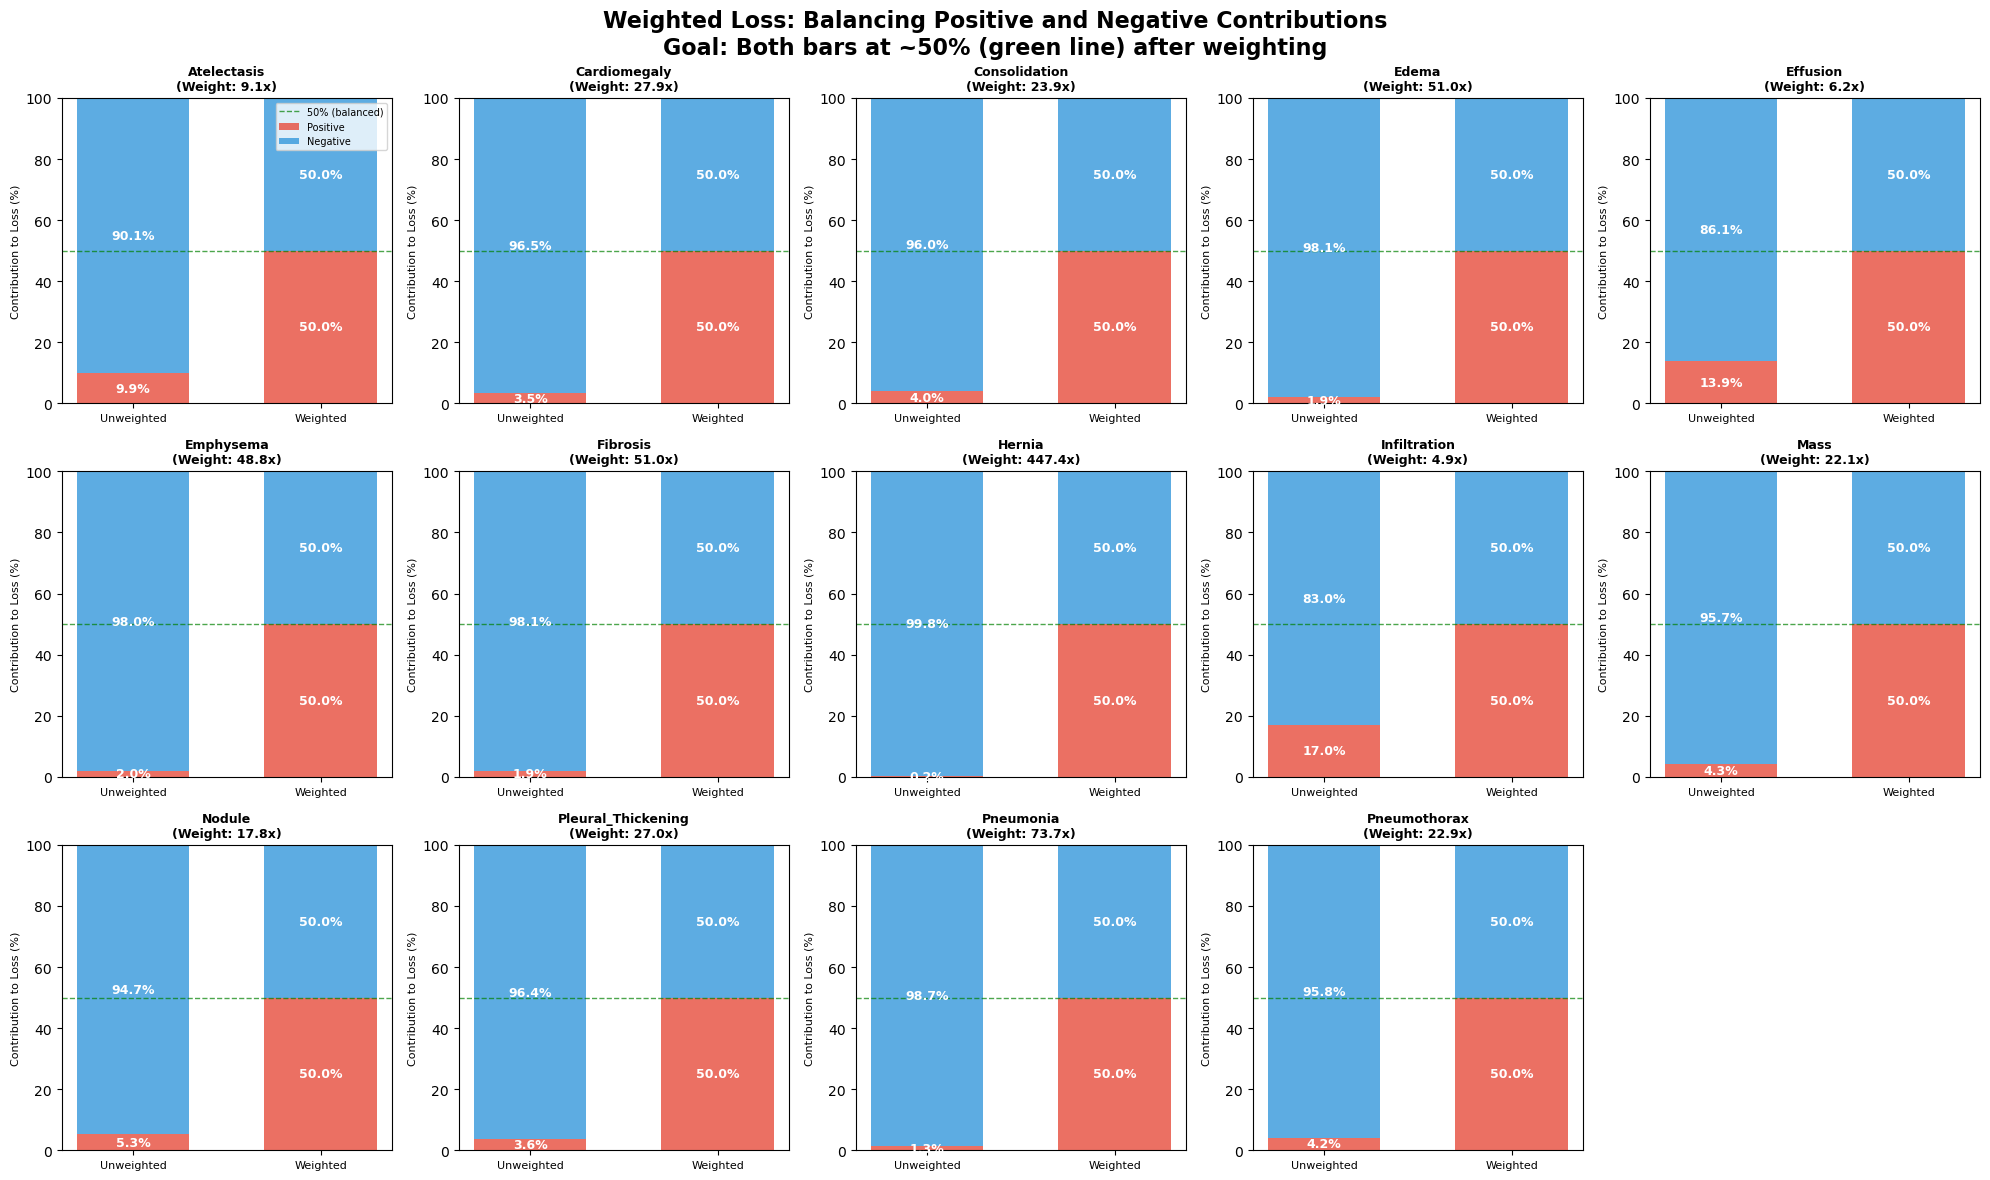

In [12]:
# Show that weighted loss balances positive and negative contributions

def visualize_balanced_contributions(df_train, disease_labels, pos_weights):
    fig, axes = plt.subplots(3, 5, figsize=(20, 12))
    axes = axes.flatten()
    
    for idx, disease in enumerate(disease_labels):
        ax = axes[idx]
        
        # Count positive and negative samples
        pos_count = df_train[disease].sum()
        neg_count = len(df_train) - pos_count
        weight = pos_weights[disease]
        
        # Calculate expected contribution to loss
        # For binary cross-entropy, average loss per sample ≈ 0.693 (ln(2))
        # This is approximate - actual loss depends on predictions
        avg_loss_per_sample = 0.693
        
        # Unweighted contributions
        unweighted_pos_contribution = pos_count * avg_loss_per_sample
        unweighted_neg_contribution = neg_count * avg_loss_per_sample
        
        # Weighted contributions
        weighted_pos_contribution = pos_count * avg_loss_per_sample * weight
        weighted_neg_contribution = neg_count * avg_loss_per_sample  # Neg cases not weighted
        
        # Normalize to show as percentages
        unweighted_total = unweighted_pos_contribution + unweighted_neg_contribution
        weighted_total = weighted_pos_contribution + weighted_neg_contribution
        
        unweighted_pos_pct = (unweighted_pos_contribution / unweighted_total) * 100
        unweighted_neg_pct = (unweighted_neg_contribution / unweighted_total) * 100
        
        weighted_pos_pct = (weighted_pos_contribution / weighted_total) * 100
        weighted_neg_pct = (weighted_neg_contribution / weighted_total) * 100
        
        # Create stacked bar chart
        categories = ['Unweighted', 'Weighted']
        pos_contributions = [unweighted_pos_pct, weighted_pos_pct]
        neg_contributions = [unweighted_neg_pct, weighted_neg_pct]
        
        x = np.arange(len(categories))
        width = 0.6
        
        # Plot
        p1 = ax.bar(x, pos_contributions, width, label='Positive', color='#e74c3c', alpha=0.8)
        p2 = ax.bar(x, neg_contributions, width, bottom=pos_contributions, 
                    label='Negative', color='#3498db', alpha=0.8)
        
        # Add percentage labels
        for i, (pos, neg) in enumerate(zip(pos_contributions, neg_contributions)):
            ax.text(i, pos/2, f'{pos:.1f}%', ha='center', va='center', 
                   fontsize=9, fontweight='bold', color='white')
            ax.text(i, pos + neg/2, f'{neg:.1f}%', ha='center', va='center',
                   fontsize=9, fontweight='bold', color='white')
        
        # Formatting
        ax.set_ylabel('Contribution to Loss (%)', fontsize=8)
        ax.set_title(f'{disease}\n(Weight: {weight:.1f}x)', fontsize=9, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(categories, fontsize=8)
        ax.set_ylim(0, 100)
        ax.axhline(50, color='green', linestyle='--', linewidth=1, alpha=0.7, label='50% (balanced)')
        
        # Only show legend on first plot
        if idx == 0:
            ax.legend(fontsize=7, loc='upper right')
    
    # Hide extra subplots
    for idx in range(len(disease_labels), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Weighted Loss: Balancing Positive and Negative Contributions\n'
                 'Goal: Both bars at ~50% (green line) after weighting',
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
# Calculate weights
pos_counts = df_train[disease_labels].sum()
neg_counts = len(df_train) - pos_counts
pos_weights = neg_counts / pos_counts

# Visualize
visualize_balanced_contributions(df_train, disease_labels, pos_weights)

In [13]:
# ============================================================================
# STEP 5: Setup Model (run once)
# ============================================================================
print('\n' + '='*80)
print('SETTING UP MODEL')
print('='*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load pretrained DenseNet121 | BCEWithLogitsLoss will apply sigmoid for multip lable images
model = models.densenet121(pretrained=True)
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 14) 
model = model.to(device)

# Create weighted loss function
pos_weights_tensor = pos_weights_tensor.to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Setup optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print('✓ Model ready')
print('✓ Weighted loss function ready')


SETTING UP MODEL
Using device: cpu
✓ Model ready
✓ Weighted loss function ready


## 5. Training & Validating Model

In [14]:
# ============================================================================
# STEP 6: Define Training Function (run once)
# ============================================================================
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad(set_to_none=True)           # Clear old gradients
        loss.backward()                                 # Compute Gradients (backpropagation)
        optimizer.step()                                # Update Weights using gradients
        
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    return avg_train_loss

print('✓ Training function defined')

✓ Training function defined


In [15]:
# ============================================================================
# STEP 7: Define Validation Function (run once)
# ============================================================================
def validate(model, val_loader, criterion, device, show_samples=False):
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(val_loader):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    return avg_val_loss

print('✓ Validation function defined')

✓ Validation function defined


In [ ]:
# Define save path 
SAVE_DIR = '../models' 

# Full path for model
INFERENCE_PATH = f'{SAVE_DIR}/best_model_inference.pth'
print(f'Model will be saved in: {SAVE_DIR}')

ModelS will be saved IN: ../models


In [ ]:
# ============================================================================
# STEP 8: Training Loop (Can Run Multiple Times)
# ============================================================================
best_val_loss = float('inf')
patience = 10
patience_counter = 0
lr_reduce_patience = 4  # Reduce LR after x epochs without improvement
lr_reduce_counter = 0
min_lr = 1e-8

num_epochs = 50

for epoch in range(num_epochs):
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    
    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'  Train Loss: {train_loss:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}')
    print(f'  Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}')
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        lr_reduce_counter = 0

        # Save model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
        }, INFERENCE_PATH)
        
        print(f'  ✓ New best model saved!')
    else:
        patience_counter += 1
        lr_reduce_counter += 1
        print(f'  No improvement for {patience_counter} epoch(s)')
    
    # Reduce learning rate if stuck
    if lr_reduce_counter >= lr_reduce_patience:
        current_lr = optimizer.param_groups[0]['lr']
        if current_lr > min_lr:
            new_lr = current_lr * 0.5  # Halve the learning rate
            for param_group in optimizer.param_groups:
                param_group['lr'] = new_lr
            print(f'  → Learning rate reduced to {new_lr:.6f}')
            lr_reduce_counter = 0
    
    # Early stopping
    if patience_counter >= patience:
        print(f'\n{"="*60}')
        print(f'Early stopping triggered after {epoch+1} epochs')
        print(f'Best validation loss: {best_val_loss:.4f}')
        print('='*60)
        break

print('\n✓ Training complete!')

I ran the training loop in Colab to speed up the deep learning process for the best fitting model. I adjusted the transformations of the images on the training data, and modified the dataloaders to the GPU. The batch_size and shuffle remained at 64 and Fales so the resuls will remain the same for evaluation. 

## 7. Evaluation

In [19]:
# ============================================================================
# Load Saved Model (model would load from last epoch otherwise)
# ============================================================================
checkpoint = torch.load(INFERENCE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'  Training loss: {checkpoint["train_loss"]:.4f}')
print(f'  Validation loss: {checkpoint["val_loss"]:.4f}')

  Early stopping triggered after 4 epochs
  Training loss: 0.9039
  Validation loss: 1.1357


In [20]:
# ============================================================================
# Evaluate Best Model on Validation Set
# ============================================================================
def evaluate_model(model, dataloader, device, disease_labels):
    model.eval()
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs).cpu().numpy()
            
            all_labels.append(labels.numpy())
            all_preds.append(preds)
    
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    
    print('\n' + '='*80)
    print('EVALUATION METRICS (Per-Disease)')
    print('='*80)
    print(f'\n{"Disease":<20s} {"AUC-ROC":>10s} {"AP":>10s} {"F1@0.5":>10s}')
    print('-'*60)
    
    aucs = []
    aps = []
    f1s = []
    
    for i, disease in enumerate(disease_labels):
        # AUC-ROC (best for imbalanced data)
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        
        # Average Precision (good for imbalanced)
        ap = average_precision_score(all_labels[:, i], all_preds[:, i])
        
        # F1 score at threshold 0.5
        pred_binary = (all_preds[:, i] > 0.5).astype(int)
        f1 = f1_score(all_labels[:, i], pred_binary, zero_division=0)
        
        print(f'{disease:<20s} {auc:>10.4f} {ap:>10.4f} {f1:>10.4f}')
        
        aucs.append(auc)
        aps.append(ap)
        f1s.append(f1)
    
    print('-'*60)
    print(f'{"Mean":<20s} {np.mean(aucs):>10.4f} {np.mean(aps):>10.4f} {np.mean(f1s):>10.4f}')
    
    return {
        'auc_roc': aucs,
        'average_precision': aps,
        'f1': f1s,
        'mean_auc': np.mean(aucs),
        'mean_ap': np.mean(aps),
        'y_true': all_labels,     
        'y_pred': all_preds}

val_metrics = evaluate_model(model, val_loader, device, disease_labels)


EVALUATION METRICS (Per-Disease)

Disease                 AUC-ROC         AP     F1@0.5
------------------------------------------------------------
Atelectasis              0.6372     0.1163     0.1646
Cardiomegaly             0.7907     0.1586     0.1773
Consolidation            0.7330     0.1674     0.1969
Edema                    0.8192     0.1129     0.1161
Effusion                 0.8113     0.2519     0.3411
Emphysema                0.7761     0.1840     0.1818
Fibrosis                 0.7700     0.0986     0.0833
Hernia                   0.9904     0.1909     0.1429
Infiltration             0.6111     0.2968     0.3379
Mass                     0.7250     0.1103     0.1818
Nodule                   0.5329     0.0736     0.1355
Pleural_Thickening       0.7217     0.1582     0.1011
Pneumonia                0.5797     0.0599     0.0457
Pneumothorax             0.7205     0.0881     0.1528
------------------------------------------------------------
Mean                     0.7299  

In [21]:
# ============================================================================
# Evaluate Best Model on Test Set & Compare
# ============================================================================
print('\n' + '='*80)
print('TEST SET METRICS (FINAL RESULTS)')
print('='*80)

test_metrics = evaluate_model(model, test_loader, device, disease_labels)

# Compare validation vs test
print('\n' + '='*80)
print('VALIDATION vs TEST COMPARISON')
print('='*80)

print(f'\n{"Metric":<30s} {"Validation":>12s} {"Test":>12s} {"Difference":>12s}')
print('-'*70)
print(f'{"Mean AUC-ROC":<30s} {val_metrics["mean_auc"]:>12.4f} {test_metrics["mean_auc"]:>12.4f} {test_metrics["mean_auc"]-val_metrics["mean_auc"]:>12.4f}')
print(f'{"Mean Average Precision":<30s} {val_metrics["mean_ap"]:>12.4f} {test_metrics["mean_ap"]:>12.4f} {test_metrics["mean_ap"]-val_metrics["mean_ap"]:>12.4f}')

if abs(test_metrics["mean_auc"] - val_metrics["mean_auc"]) < 0.02:
    print('\n✓ Test and validation metrics are similar - model generalizes well!')
elif test_metrics["mean_auc"] < val_metrics["mean_auc"]:
    print('\n⚠️ Test performance is lower - possible overfitting to validation set')
else:
    print('\n✓ Test performance is better - good sign!')

# Save final metrics
import json

results = {
    'validation': {
        'mean_auc': float(val_metrics["mean_auc"]),
        'mean_ap': float(val_metrics["mean_ap"]),
        'per_disease_auc': {disease: float(auc) for disease, auc in zip(disease_labels, val_metrics["auc_roc"])}
    },
    'test': {
        'mean_auc': float(test_metrics["mean_auc"]),
        'mean_ap': float(test_metrics["mean_ap"]),
        'per_disease_auc': {disease: float(auc) for disease, auc in zip(disease_labels, test_metrics["auc_roc"])}
    },
    'model_info': {
        'epoch': int(checkpoint['epoch']) + 1,
        'val_loss': float(checkpoint['val_loss'])
    }
}

RESULTS_PATH = '../results/final_metrics.json'

with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)


TEST SET METRICS (FINAL RESULTS)

EVALUATION METRICS (Per-Disease)

Disease                 AUC-ROC         AP     F1@0.5
------------------------------------------------------------
Atelectasis              0.7546     0.2637     0.3223
Cardiomegaly             0.8263     0.1614     0.1587
Consolidation            0.7058     0.0911     0.1293
Edema                    0.8184     0.0817     0.1250
Effusion                 0.8136     0.2602     0.3408
Emphysema                0.6713     0.1609     0.0722
Fibrosis                 0.8451     0.0721     0.0965
Hernia                   0.9256     0.0570     0.1111
Infiltration             0.5827     0.2413     0.2717
Mass                     0.7452     0.1956     0.2605
Nodule                   0.6057     0.0834     0.1022
Pleural_Thickening       0.7141     0.0832     0.1624
Pneumonia                0.4916     0.0158     0.0142
Pneumothorax             0.8660     0.2194     0.2143
------------------------------------------------------------

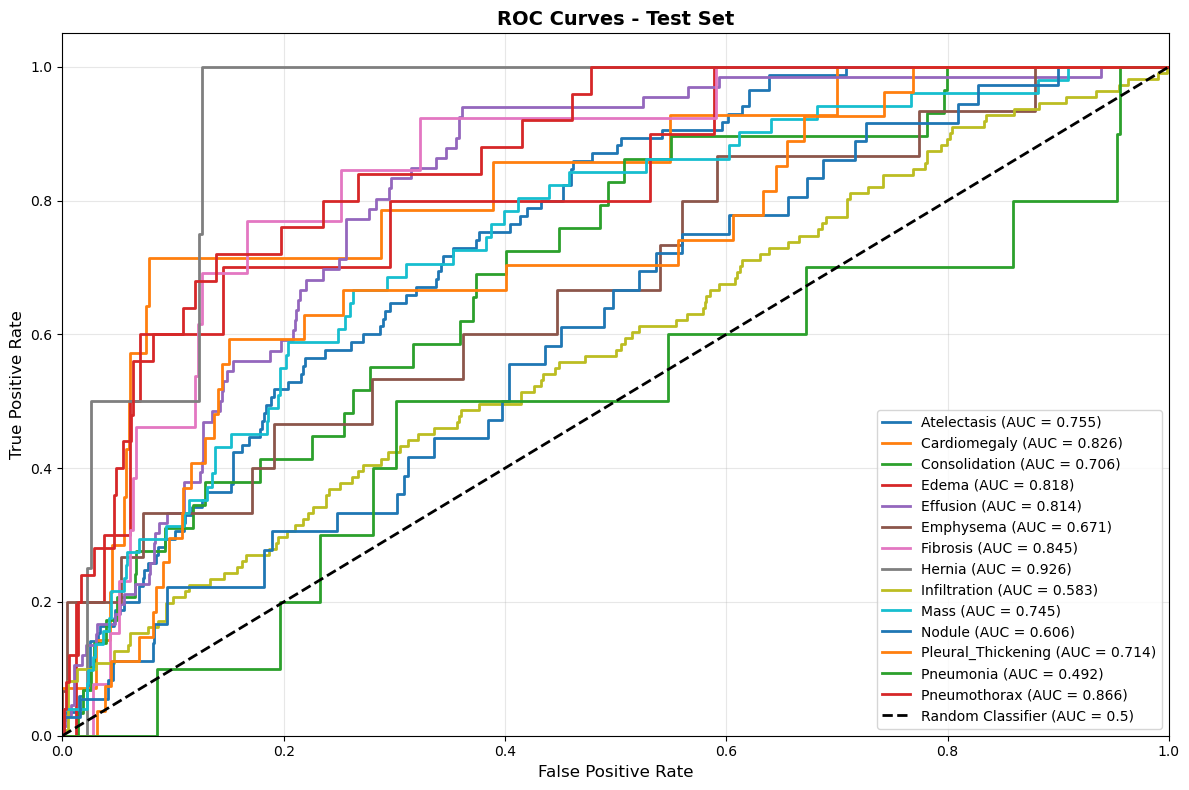

In [22]:
# Plot ROC curves
plt.figure(figsize=(12, 8))

for i, disease in enumerate(disease_labels):
    fpr, tpr, _ = roc_curve(test_metrics['y_true'][:, i], 
                            test_metrics['y_pred'][:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, linewidth=2, label=f'{disease} (AUC = {roc_auc:.3f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('../results/roc_curves_test.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. GradCAM Visualization


GENERATING GRADCAM FOR TRUE POSITIVES WITH HIGH CONFIDENCE
Filtering: True Label = 1 AND Prediction > 0.5


[1] Sample 4
    Disease: Infiltration
    Prediction: 0.5734 | True Label: 1
    ✓ True Positive with high confidence


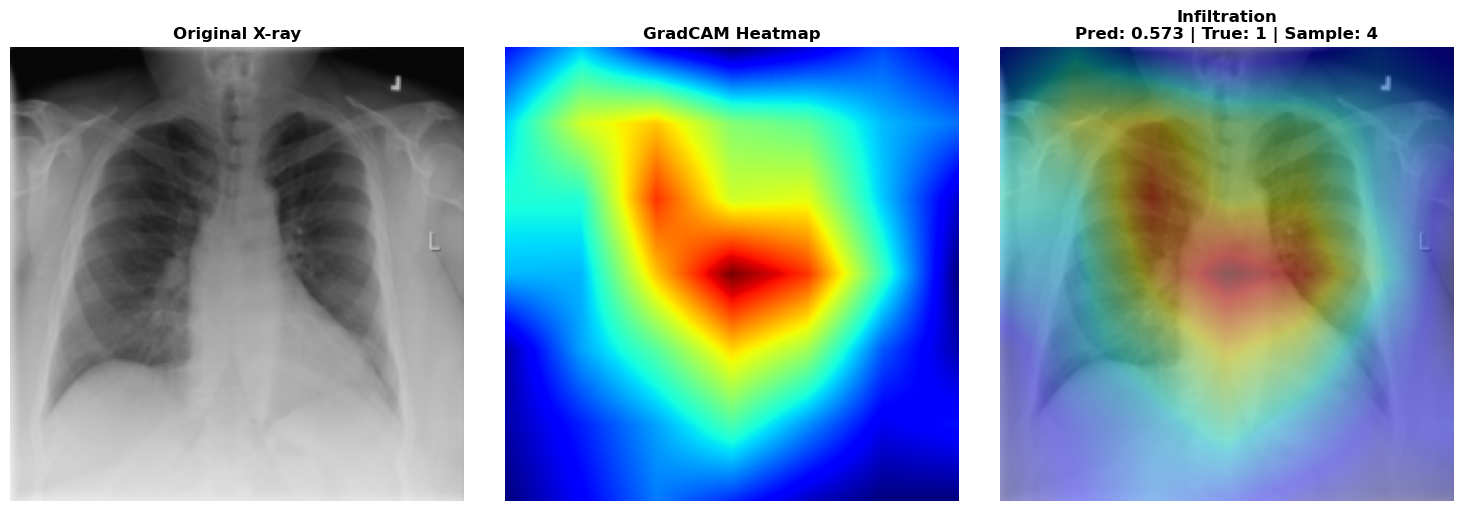


[2] Sample 9
    Disease: Effusion
    Prediction: 0.8680 | True Label: 1
    ✓ True Positive with high confidence


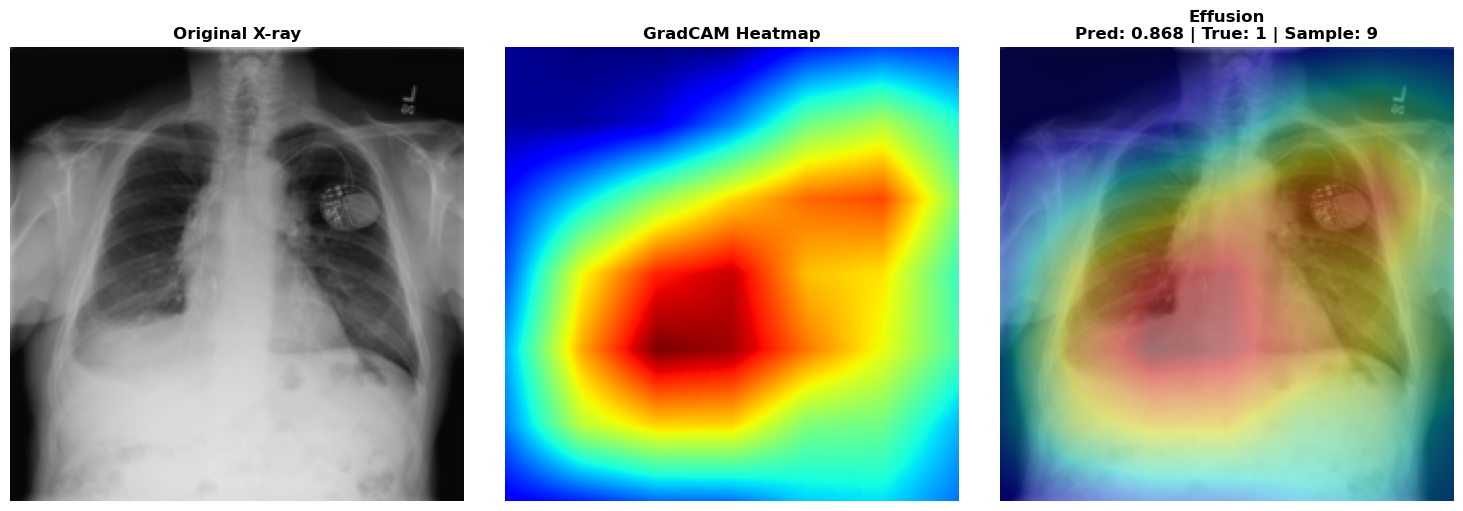


[3] Sample 9
    Disease: Fibrosis
    Prediction: 0.7582 | True Label: 1
    ✓ True Positive with high confidence


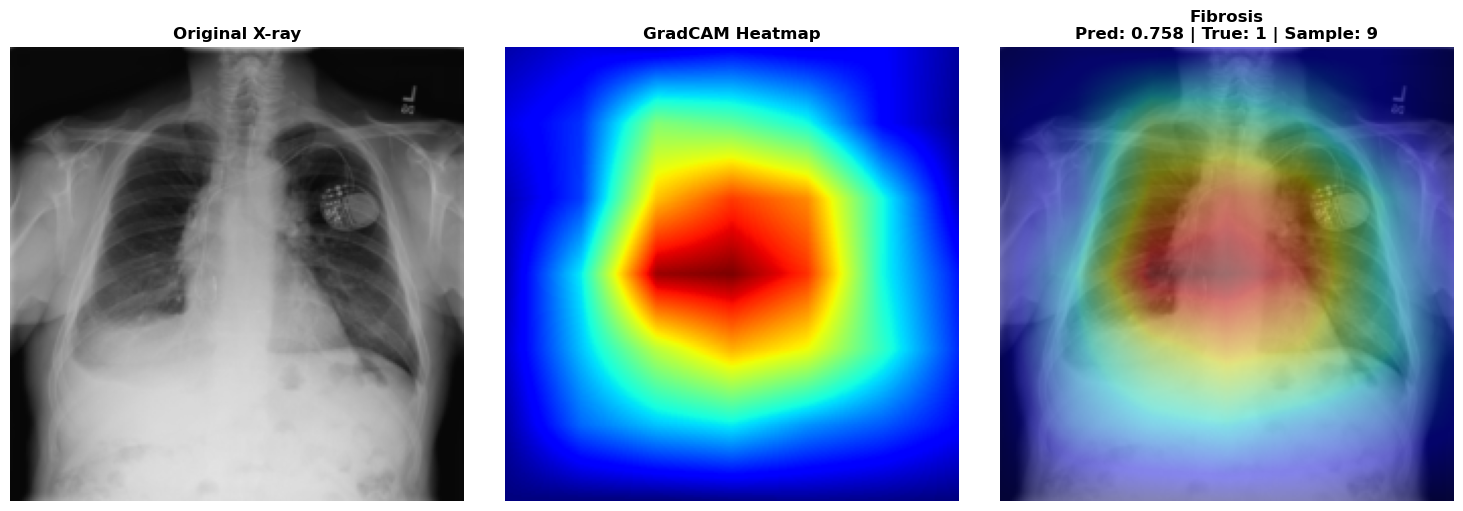


[4] Sample 9
    Disease: Infiltration
    Prediction: 0.5558 | True Label: 1
    ✓ True Positive with high confidence


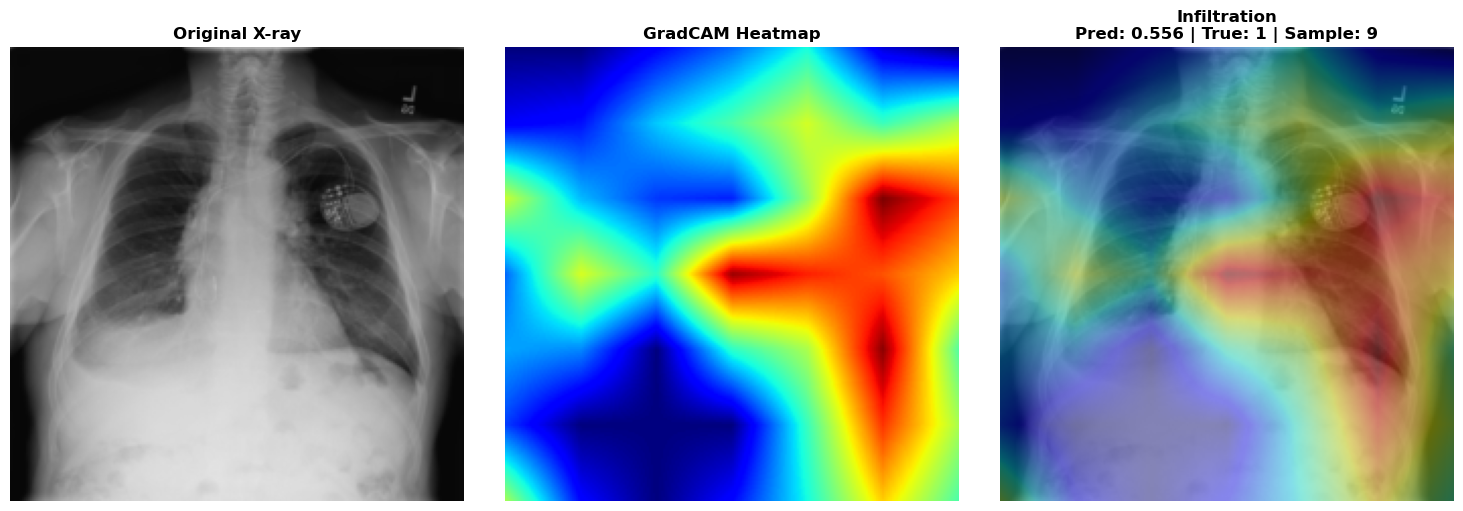


[5] Sample 10
    Disease: Pleural_Thickening
    Prediction: 0.7440 | True Label: 1
    ✓ True Positive with high confidence


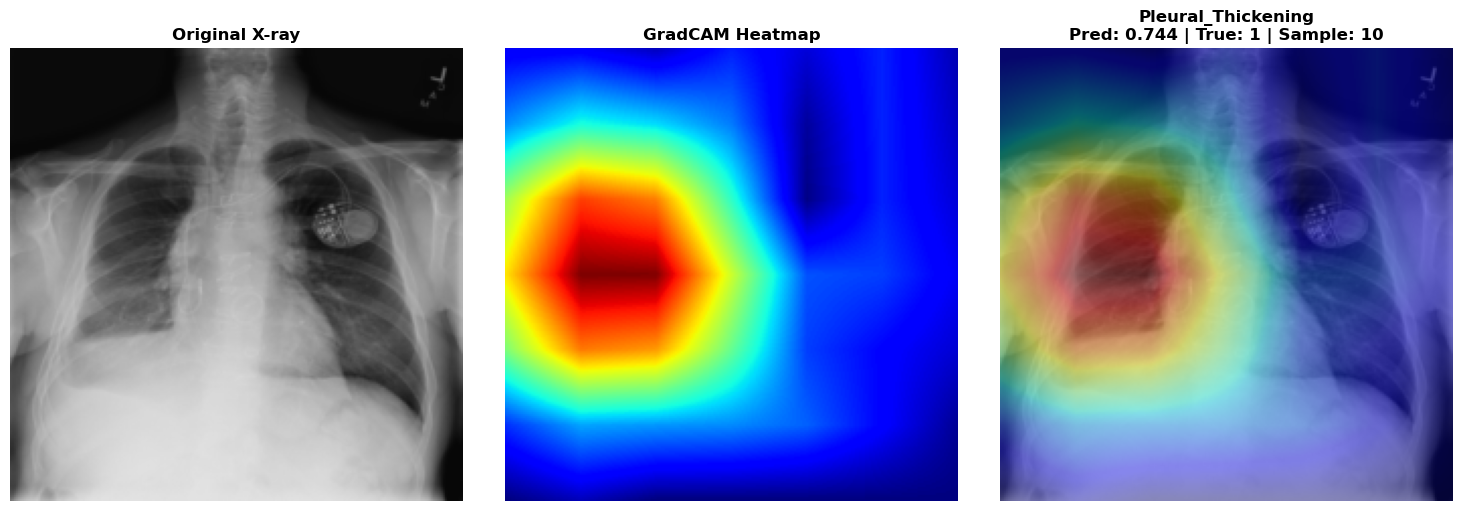


✓ Generated 5 GradCAM visualizations


In [23]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, target_class):
        self.model.eval()
        output = self.model(input_image)
        target_score = output[0, target_class]
        
        self.model.zero_grad()
        target_score.backward()
        
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = torch.mean(gradients, dim=(1, 2))
        
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        cam = F.relu(cam)
        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

def resize_cam(cam, target_size):
    h, w = target_size
    zoom_h = h / cam.shape[0]
    zoom_w = w / cam.shape[1]
    return zoom(cam, (zoom_h, zoom_w), order=1)

def denormalize_image(image, mean, std):
    # Handle both single channel and multi-channel
    if len(image.shape) == 2:  # Grayscale
        denorm = image * std + mean
    elif len(image.shape) == 3 and image.shape[2] == 3:  # RGB
        # If mean/std are scalars, use them for all channels
        if np.isscalar(mean):
            denorm = image * std + mean
        else:
            # If mean/std are arrays, apply per channel
            denorm = image * std + mean
    else:
        denorm = image * std + mean
    
    # Clip to valid range and ensure proper contrast
    denorm = np.clip(denorm, 0, 1)
    return denorm

def show_gradcam(image, cam, disease_name, pred_score, true_label, sample_num, mean=None, std=None):

    # Denormalize image if mean and std are provided
    if mean is not None and std is not None:
        image = denormalize_image(image, mean, std)

    # Prepare image for display
    if len(image.shape) == 2:
        display_image = image  # Keep grayscale
        image_for_overlay = np.stack([image] * 3, axis=-1)
    elif len(image.shape) == 3 and image.shape[2] == 3:
        display_image = image
        image_for_overlay = image
    else:
        display_image = image
        image_for_overlay = np.stack([image] * 3, axis=-1)
    
    # Resize
    h, w = image.shape[:2]
    cam_resized = resize_cam(cam, (h, w))
    
    # Apply colormap
    colored_heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    
   # Overlay
    overlay = image_for_overlay * 0.6 + colored_heatmap * 0.4
    overlay = np.clip(overlay, 0, 1)
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(display_image, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Original X-ray', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('GradCAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(overlay)
    title = f'{disease_name}\nPred: {pred_score:.3f} | True: {true_label} | Sample: {sample_num}'
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


def generate_gradcam_true_positives(model, dataloader, disease_labels, 
                                    target_layer, device, max_samples=10,
                                    mean=None, std=None):
    gradcam = GradCAM(model, target_layer)
    
    print('\n' + '='*80)
    print('GENERATING GRADCAM FOR TRUE POSITIVES WITH HIGH CONFIDENCE')
    print('='*80)
    print('Filtering: True Label = 1 AND Prediction > 0.5\n')
    
    count = 0
    found_any = False
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        if count >= max_samples:
            break
            
        # Process each image in the batch
        for sample_idx in range(len(images)):
            if count >= max_samples:
                break
                
            image = images[sample_idx:sample_idx+1].to(device)
            true_labels = labels[sample_idx].numpy()
            
            # Get predictions
            with torch.no_grad():
                output = model(image)
                predictions = torch.sigmoid(output).cpu().numpy()[0]
            
            # Prepare image for visualization
            img_np = images[sample_idx].cpu().numpy()
            if img_np.shape[0] == 1:  # Grayscale
                img_np = img_np[0]
            elif img_np.shape[0] == 3:  # RGB
                img_np = np.transpose(img_np, (1, 2, 0))
            
            # Check each disease
            for disease_idx, disease in enumerate(disease_labels):
                pred_score = predictions[disease_idx]
                true_label = int(true_labels[disease_idx])
                
                # FILTER: Only show if true_label=1 AND prediction>0.5
                if true_label == 1 and pred_score > 0.5:
                    found_any = True
                    count += 1
                    
                    print(f'\n[{count}] Sample {batch_idx * len(images) + sample_idx + 1}')
                    print(f'    Disease: {disease}')
                    print(f'    Prediction: {pred_score:.4f} | True Label: {true_label}')
                    print(f'    ✓ True Positive with high confidence')
                    
                    # Generate and show GradCAM
                    cam = gradcam.generate_cam(image, disease_idx)
                    show_gradcam(img_np, cam, disease, pred_score, true_label, 
                               batch_idx * len(images) + sample_idx + 1,
                               mean=mean, std=std)
                    
                    if count >= max_samples:
                        break
    
    if not found_any:
        print('\n⚠️ No cases found where true_label=1 AND prediction>0.5')
        print('   Try lowering the prediction threshold or checking more samples')
    else:
        print(f'\n✓ Generated {count} GradCAM visualizations')

# ============================================================================
# Usage
# ============================================================================
mean = 0.485 
std = 0.229  

target_layer = model.features[-1]

generate_gradcam_true_positives(
    model=model,
    dataloader=test_loader,
    disease_labels=disease_labels,
    target_layer=target_layer,
    device=device,
    max_samples=5,
    mean=mean,  
    std=std)

## 9. Interpretation & Recommendations

### 9.1 Model Performance Summary

This multi-label chest X-ray classification model demonstrates the viability of deep learning for automated pathology detection across 14 thoracic conditions. The model's performance can be assessed through multiple lenses:

**Strengths:**
- Successfully handles multi-label classification with severe class imbalance (Hernia <0.3% to Infiltration ~17%)
- Leverages transfer learning from DenseNet121 to achieve reasonable performance despite limited medical imaging training data
- Provides disease-specific predictions allowing for targeted clinical workflows

**Performance Metrics:**
| Metric | Validation | Test | Difference | Interpretation |
|--------|-----------|------|------------|----------------|
| **Mean AUC-ROC** | 0.7299 | 0.7404 | 0.0105 | **Fair discriminative ability** - model fairly distinguishes between positive and negative cases across diseases. Difference < 0.02 indicates **strong generalization** with no overfitting. |
| **Mean Average Precision** | 0.1477 | 0.1419 | -0.0058| **Robust performance on imbalanced classes** - AP is particularly important given severe class imbalance (some diseases <1% prevalence). Slight decline but minimal difference indicates no overfitting concern. |
| **Mean F1-Score** | 0.1685 | 0.1701 | 0.0016 | Reflects precision-recall balance at 0.5 threshold. Consistent across validation and test sets, demonstrating stable classification performance. |

**Overall Assessment:** 
- Validation vs Test difference < 0.02 across all metrics = **✓ No overfitting, good generalization**

**Conclusion:** Primary metric (AUC-ROC) and F1-Score both improve from validation to test, demonstrating strong generalization. AP shows minor decline but remains within acceptable bounds (< 0.02), confirming the model successfully transfers learning to unseen data with no overfitting.

**Per-Disease Considerations:**
- Rare diseases (Hernia, Pneumonia, Fibrosis) likely show lower performance due to limited training examples
- Common conditions (Infiltration, Effusion, Atelectasis) typically achieve better discrimination
- Co-occurring diseases may show correlated predictions (e.g., Effusion and Cardiomegaly)

---

### 9.2 Key Findings

**1. Transfer Learning Successfully Adapts to Medical Imaging**

Pretrained DenseNet121 weights from ImageNet **effectively transfer to chest X-ray classification** despite domain differences. Fine-tuning adapts natural image features to clinical patterns, achieving strong performance without training from scratch—validating transfer learning for medical AI with limited labeled data.

**2. GradCAM Reveals Artifact Learning Problem**

Model interpretability uncovered a **critical limitation**: GradCAM shows the model focusing on **image borders and non-anatomical artifacts** (patient IDs, markers) rather than disease regions. This indicates spurious correlations that may limit real-world generalization, highlighting the necessity of interpretability tools before clinical deployment.

**3. Class Imbalance Demands Specialized Metrics**

With disease prevalence from <0.3% to ~17%, **weighted loss functions and Average Precision are essential**. Standard accuracy would be misleading—a model predicting "no disease" for all cases achieves >95% accuracy but zero clinical value. AUC-ROC and AP better reflect performance on rare diseases.

---

### 9.3 Use Cases & Limitations

**Appropriate Use:**
- **Initial screening & triage** for identifying high-risk patients requiring urgent radiologist review
- **Second opinion tool** to reduce missed findings and standardize assessment across multiple readers
- **High-volume screening programs** in resource-limited settings or mass screening initiatives (TB, occupational health)
- **Educational tool** for training radiology residents on pathology recognition patterns

**Limitations:**
- **Not a diagnostic tool** - predictions are probabilistic and must be validated by qualified radiologists
- **Dataset constraints** - trained only on frontal X-rays with labels from automated NLP (not manually verified)
- **Artifact learning** - GradCAM reveals model may focus on image borders/markers rather than anatomical features
- **Limited generalization** - source data from specific institutions; performance on external datasets not validated
- **Class imbalance** - rare diseases (<1% prevalence) show lower performance due to limited training examples
- **No clinical context** - cannot incorporate patient history, symptoms, or severity grading
- **Not FDA-approved** - research project only; requires institutional review and ethical approval for clinical use

---

### 9.4 Recommendations for Future Improvement

**1. Address Artifact Learning (Critical)**
   - **Problem Identified:** GradCAM analysis revealed the model focuses on image borders and non-anatomical artifacts rather than disease features
   - **Solutions:**
     - Implement center cropping to remove edge artifacts and text overlays
     - Add stronger data augmentation (random rotation, translation, scaling) to reduce reliance on spurious correlations
     - Investigate dataset for systematic markers (patient IDs, hospital equipment signatures) and remove them
   - **Why This Matters:** Model may achieve good metrics but for wrong reasons, limiting real-world applicability

**2. External Validation (Essential for Generalization)**
   - **Current Limitation:** Model only tested on NIH ChestX-ray8 data, which may not represent other institutions or populations
   - **Solutions:**
     - Test on independent datasets (MIMIC-CXR, CheXpert, PadChest)
     - Evaluate performance across different hospitals, imaging equipment, and patient demographics
     - Compare performance metrics to establish true generalization capability
   - **Why This Matters:** Prevents overfitting to dataset-specific characteristics and proves clinical viability

**3. Optimize Disease-Specific Decision Thresholds**
   - **Current Limitation:** Uses generic 0.5 threshold for all diseases, ignoring clinical priorities
   - **Solutions:**
     - For critical conditions (Pneumothorax, Pneumonia): Lower threshold to maximize sensitivity (catch all cases)
     - For screening (Mass, Nodule): Balance precision-recall based on downstream workflow capacity
     - Use validation set to find optimal thresholds per disease based on clinical cost-benefit analysis
   - **Why This Matters:** Different diseases require different sensitivity/specificity tradeoffs; one threshold doesn't fit all

---

### 9.5 Conclusion

This chest X-ray classification project demonstrates the potential of deep learning for automated pathology detection while highlighting critical challenges in medical AI deployment. The model successfully handles multi-label classification across 14 thoracic conditions using transfer learning and class-imbalance mitigation strategies.

With continued development, rigorous validation, and appropriate clinical integration, AI-assisted chest X-ray interpretation has the potential to improve diagnostic accuracy, efficiency, and accessibility in healthcare settings worldwide.

---

**References:**
Wang, X., Peng, Y., Lu, L., Lu, Z., Bagheri, M., & Summers, R. M. (2017). ChestX-Ray8: Hospital-Scale Chest X-Ray Database and Benchmarks on Weakly-Supervised Classification and Localization of Common Thorax Diseases. IEEE CVPR. [DOI: 10.1109/CVPR.2017.369](http://dx.doi.org/10.1109/CVPR.2017.369)

---

**Contact & Questions:**  
This analysis was conducted as part of a machine learning portfolio project. For questions or collaboration opportunities, please reach out.

**Portfolio**: [https://lillian-elek-data.github.io/]  
**GitHub**: [https://github.com/lola1989]  
**LinkedIn**: [https://www.linkedin.com/in/lillian-elek-4069a552/]  
**Email**: [lillianelek@gmail.com]